### Hello! this is an attempt to do audio analysis of MP3 file by first exploring the correct library and then finding out the tempo of the audio. As a non-experienced audio person I did some research and found out that Librosa is a reliable library supported by many to perform basic tasks in Python for audio analysis. So lets import the libraries. 

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

#### Here y receives the audio as a waveform and sr is Sample Rate which basically is nothing but in lame language how many snapshots of sound we take in a second. After doing some research I found out that 44,100 Hz is usually good enough for standard CD quality audio.

In [5]:
file_path = "loudly.mp3"
y, sr = librosa.load(file_path, sr=None)  
duration = librosa.get_duration(y=y, sr=sr)

In [6]:
print(y)
print(sr)
print(duration)

[-1.7786724e-04 -2.2421876e-04 -2.2738444e-04 ... -1.7288176e-06
 -2.0032608e-06  5.2458188e-07]
44100
24.006802721088434


#### Let's listen to the audio!

In [7]:
import IPython.display as ipd
ipd.Audio(file_path)

#### After listening to it I can recognize the different instruments being played. Out of which one is of a higher frequency. The rhythm of the audio sounds to be regular which is good. Groovy music. 

In [8]:
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

#### Convert beat frames to time

In [9]:
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

### Print the estimated tempo and beat positions

In [11]:
print(f"Estimated Tempo: {tempo[0]:.2f} BPM")
print(f"Beat Times (seconds): {beat_times}")

Estimated Tempo: 90.67 BPM
Beat Times (seconds): [ 3.35528345  4.02866213  4.67882086  5.36380952  6.01396825  6.68734694
  7.34911565  8.02249433  8.68426304  9.35764172 10.01941043 10.69278912
 11.35455782 12.01632653 12.67809524 13.35147392 14.01324263 14.68662132
 15.34839002 16.02176871 16.68353741 17.3569161  18.01868481 18.69206349
 19.3538322  20.02721088 20.67736961 21.36235828 22.02412698 22.68589569]


#### Let's plot the waveforms.

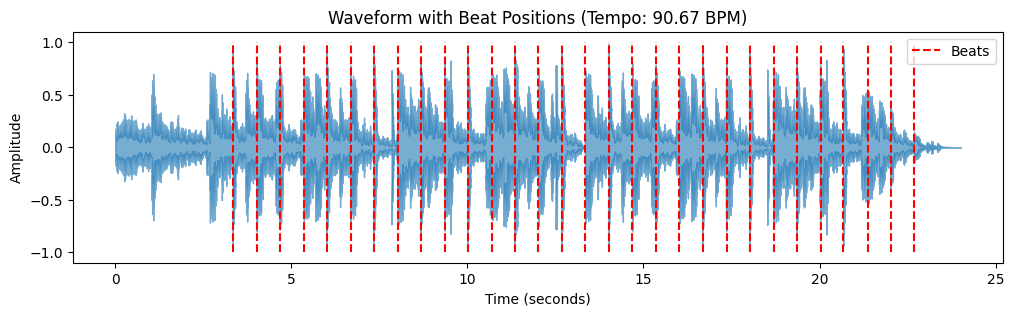

In [12]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.vlines(beat_times, ymin=-1, ymax=1, color='r', linestyle='--', label="Beats")
plt.title(f"Waveform with Beat Positions (Tempo: {tempo[0]:.2f} BPM)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

#### Let's try to make it more clear

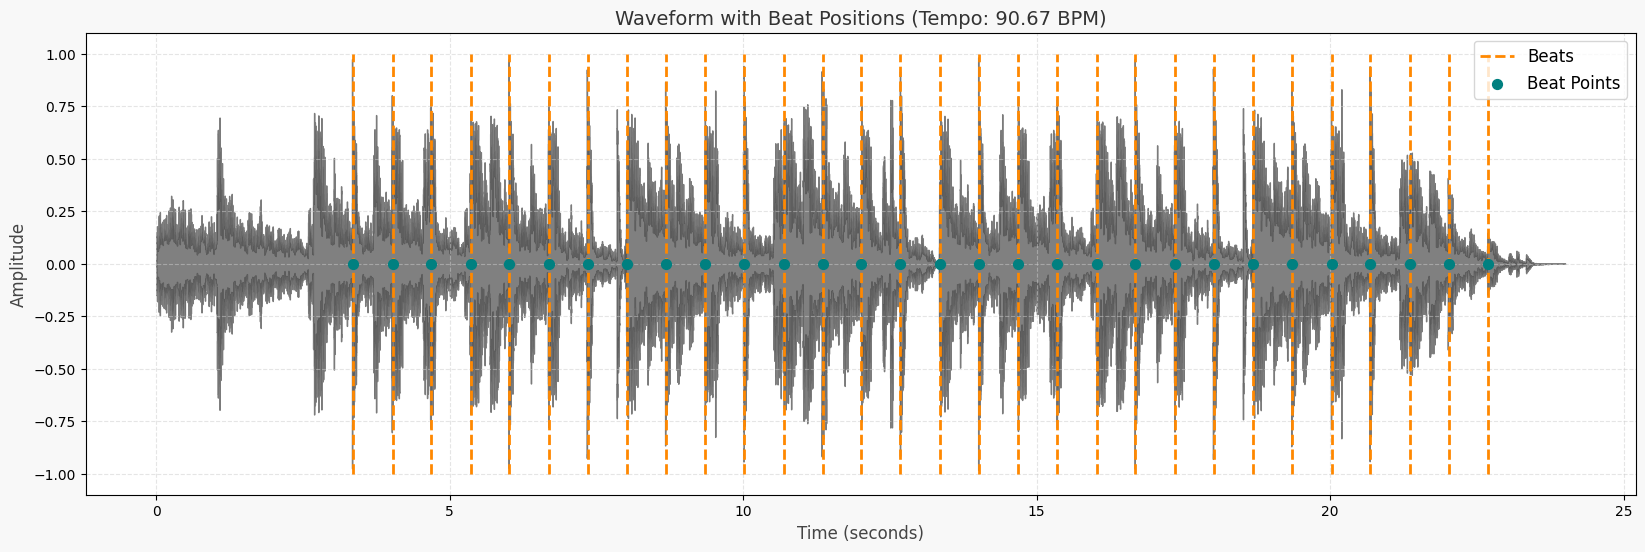

In [13]:
plt.figure(figsize=(20, 6), facecolor="#f8f8f8")

librosa.display.waveshow(y, sr=sr, alpha=0.7, color='#4a4a4a')

plt.vlines(beat_times, ymin=-1, ymax=1, color='#ff8800', linestyle='--', linewidth=2, label="Beats")

plt.scatter(beat_times, np.zeros_like(beat_times), color='#008080', s=50, label="Beat Points", zorder=3)

plt.title(f"Waveform with Beat Positions (Tempo: {tempo[0]:.2f} BPM)", fontsize=14, color="#333333")
plt.xlabel("Time (seconds)", fontsize=12, color="#444444")
plt.ylabel("Amplitude", fontsize=12, color="#444444")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", color="#cccccc", alpha=0.5)  # Light gray grid
plt.show()

#### Plot the beats more clearly on a separate subplot

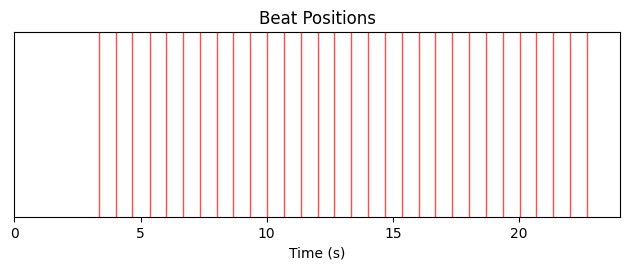

In [14]:
plt.subplot(2, 1, 2)
plt.title("Beat Positions")
plt.xlabel("Time (s)")

for beat_time in beat_times:
    plt.axvline(x=beat_time, color='r', alpha=0.7, linewidth=1)

plt.xlim(0, duration)
plt.yticks([])

plt.tight_layout()
plt.show()